# Visão Geral do Dataset: Credit Card Fraud Detection

Este dataset é um dos mais conhecidos para estudos em **detecção de fraudes** e **análise de anomalias**. Ele contém transações com cartão de crédito realizadas por europeus em setembro de 2013.

## Por que usá-lo?

A principal característica que o torna perfeito para este tipo de análise é o seu **desequilíbrio extremo (imbalance)** . As transações fraudulentas são eventos raros, funcionando como anomalias em meio ao grande volume de transações legítimas.

- **Total de transações:** 284.807
- **Transações fraudulentas (Classe 1):** 492 (apenas **0,172%** do total)
- **Transações legítimas (Classe 0):** 284.315

Esse cenário reflete fielmente o mundo real, onde a grande maioria das transações é normal e as fraudes são a exceção.

## Estrutura dos Dados

O dataset possui 31 colunas, todas numéricas. Devido a questões de confidencialidade, os dados originais foram transformados por meio da técnica de **Análise de Componentes Principais (PCA)** .

| Colunas | Descrição |
| :--- | :--- |
| **`Time`** | Segundos decorridos entre a primeira transação do dataset e a transação atual. |
| **`V1` a `V28`** | Resultado da transformação PCA das características originais. São as principais variáveis para a modelagem. |
| **`Amount`** | Valor da transação. Pode ser usado para aprendizado sensível ao custo. |
| **`Class`** | **Variável alvo (resposta).** <br> • `0` = Transação legítima (classe majoritária) <br> • `1` = Transação fraudulenta (classe minoritária, a anomalia) |

## PCA (Principal Component Analysis)

**PCA** é uma técnica de redução de dimensionalidade que transforma um conjunto de variáveis originais em um novo conjunto de variáveis não correlacionadas chamadas **componentes principais**.

### Por que foi usado neste dataset?

- Os dados originais de transações são **confidenciais**
- O PCA foi aplicado para **anonimizar** as features
- As 28 componentes (V1 a V28) preservam as relações estatísticas sem expor informações sensíveis

### Características das features PCA:

- **Não têm unidade** — são apenas números
- **Média ≈ 0** — centralizadas em zero
- **Não correlacionadas** entre si
- **Não precisam de normalização** - seus valores tem pesos diferentes **propositalmente** conforme a relevância para o resultado final

### No dataset:

- `Time` e `Amount` são as únicas colunas **não transformadas** por PCA
- `Class` é a variável alvo (1 = fraude, 0 = normal)

## Citação e Referência

Se você utilizar este dataset, é solicitado que cite o trabalho original:

> Andrea Dal Pozzolo, Olivier Caelen, Reid A. Johnson and Gianluca Bontempi. *Calibrating Probability with Undersampling for Unbalanced Classification.* In Symposium on Computational Intelligence and Data Mining (CIDM), IEEE, 2015.

# Análise inicial

Vamos ver o dataset resumidamente:

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

df = pd.read_csv('datasets/creditcard.csv')
print(df.head())

   Time        V1        V2        V3        V4        V5        V6        V7  \
0   0.0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1   0.0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2   1.0 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3   1.0 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4   2.0 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9  ...       V21       V22       V23       V24       V25  \
0  0.098698  0.363787  ... -0.018307  0.277838 -0.110474  0.066928  0.128539   
1  0.085102 -0.255425  ... -0.225775 -0.638672  0.101288 -0.339846  0.167170   
2  0.247676 -1.514654  ...  0.247998  0.771679  0.909412 -0.689281 -0.327642   
3  0.377436 -1.387024  ... -0.108300  0.005274 -0.190321 -1.175575  0.647376   
4 -0.270533  0.817739  ... -0.009431  0.798278 -0.137458  0.141267 -0.206010   

        V26       V27       V28 

In [19]:
print("\nRESUMO COMPLETO:")
print(df.describe().round(2))


RESUMO COMPLETO:
            Time         V1         V2         V3         V4         V5  \
count  284807.00  284807.00  284807.00  284807.00  284807.00  284807.00   
mean    94813.86       0.00       0.00      -0.00       0.00       0.00   
std     47488.15       1.96       1.65       1.52       1.42       1.38   
min         0.00     -56.41     -72.72     -48.33      -5.68    -113.74   
25%     54201.50      -0.92      -0.60      -0.89      -0.85      -0.69   
50%     84692.00       0.02       0.07       0.18      -0.02      -0.05   
75%    139320.50       1.32       0.80       1.03       0.74       0.61   
max    172792.00       2.45      22.06       9.38      16.88      34.80   

              V6         V7         V8         V9  ...        V21        V22  \
count  284807.00  284807.00  284807.00  284807.00  ...  284807.00  284807.00   
mean        0.00      -0.00       0.00      -0.00  ...       0.00      -0.00   
std         1.33       1.24       1.19       1.10  ...       0.73 

## Verificação de nulos por coluna:

In [12]:
df.isnull().sum()

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

In [21]:
fraudes = df['Class'].sum()
total = len(df)
print(f"\n💳 FRAUDES: {fraudes} ({fraudes/total*100:.4f}%)")
print(f"✅ NORMAIS: {total - fraudes} ({100 - fraudes/total*100:.4f}%)")


print("\nTRANSACTION AMOUNT:")
print(f"   Mínimo: R$ {df['Amount'].min():.2f}")
print(f"   Máximo: R$ {df['Amount'].max():.2f}")
print(f"   Média:  R$ {df['Amount'].mean():.2f}")
print(f"   Mediana: R$ {df['Amount'].median():.2f}")

negativos = (df['Amount'] < 0).sum()
print(f"\nAMOUNT NEGATIVO: {negativos} {'✅' if negativos == 0 else '⚠️ INCONSISTÊNCIA!'}")

print(f"\nTIME:")
print(f"   Min: {df['Time'].min()} segundos")
print(f"   Max: {df['Time'].max()} segundos")
print(f"   Duração: {(df['Time'].max() - df['Time'].min())/3600:.1f} horas")

features_pca = [f'V{i}' for i in range(1, 29)]
infinitos = df[features_pca].isin([np.inf, -np.inf]).sum().sum()
print(f"\n (V1-V28): {infinitos} infinitos {'✅' if infinitos == 0 else '⚠️'}")



💳 FRAUDES: 492 (0.1727%)
✅ NORMAIS: 284315 (99.8273%)

TRANSACTION AMOUNT:
   Mínimo: R$ 0.00
   Máximo: R$ 25691.16
   Média:  R$ 88.35
   Mediana: R$ 22.00

AMOUNT NEGATIVO: 0 ✅

TIME:
   Min: 0.0 segundos
   Max: 172792.0 segundos
   Duração: 48.0 horas

 (V1-V28): 0 infinitos ✅


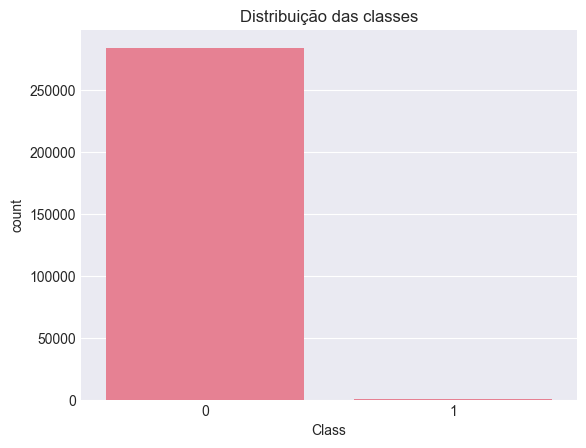

In [33]:
sns.countplot(x='Class', data=df)
plt.title('Distribuição das classes')
plt.show()

Feitas as verificações para a prática, pois este dataset é conhecido por não ter nulos, nem problemas nos dados. Somente que é um dataset desbalanceado: pouquíssimas fraudes (0.1727%). O que se vê no gráfico acima.

Agora, vamos verificar a presença de outliers. Somente pela prática.

# Outliers

In [23]:
df_num = df.select_dtypes(include=[np.number])

for col in df_num.columns:
    Q1 = df_num[col].quantile(0.25)
    Q3 = df_num[col].quantile(0.75)
    IQR = Q3 - Q1
    outliers = df_num[(df_num[col] < Q1 - 1.5*IQR) | (df_num[col] > Q3 + 1.5*IQR)]
    
    if len(outliers) > 0:
        print(f"{col}: {len(outliers)} outliers ({len(outliers)/len(df_num)*100:.1f}%)")

V1: 7062 outliers (2.5%)
V2: 13526 outliers (4.7%)
V3: 3363 outliers (1.2%)
V4: 11148 outliers (3.9%)
V5: 12295 outliers (4.3%)
V6: 22965 outliers (8.1%)
V7: 8948 outliers (3.1%)
V8: 24134 outliers (8.5%)
V9: 8283 outliers (2.9%)
V10: 9496 outliers (3.3%)
V11: 780 outliers (0.3%)
V12: 15348 outliers (5.4%)
V13: 3368 outliers (1.2%)
V14: 14149 outliers (5.0%)
V15: 2894 outliers (1.0%)
V16: 8184 outliers (2.9%)
V17: 7420 outliers (2.6%)
V18: 7533 outliers (2.6%)
V19: 10205 outliers (3.6%)
V20: 27770 outliers (9.8%)
V21: 14497 outliers (5.1%)
V22: 1317 outliers (0.5%)
V23: 18541 outliers (6.5%)
V24: 4774 outliers (1.7%)
V25: 5367 outliers (1.9%)
V26: 5596 outliers (2.0%)
V27: 39163 outliers (13.8%)
V28: 30342 outliers (10.7%)
Amount: 31904 outliers (11.2%)
Class: 492 outliers (0.2%)


Representação gráfica de algumas colunas com gráficos violino (para facilitar a leitura):

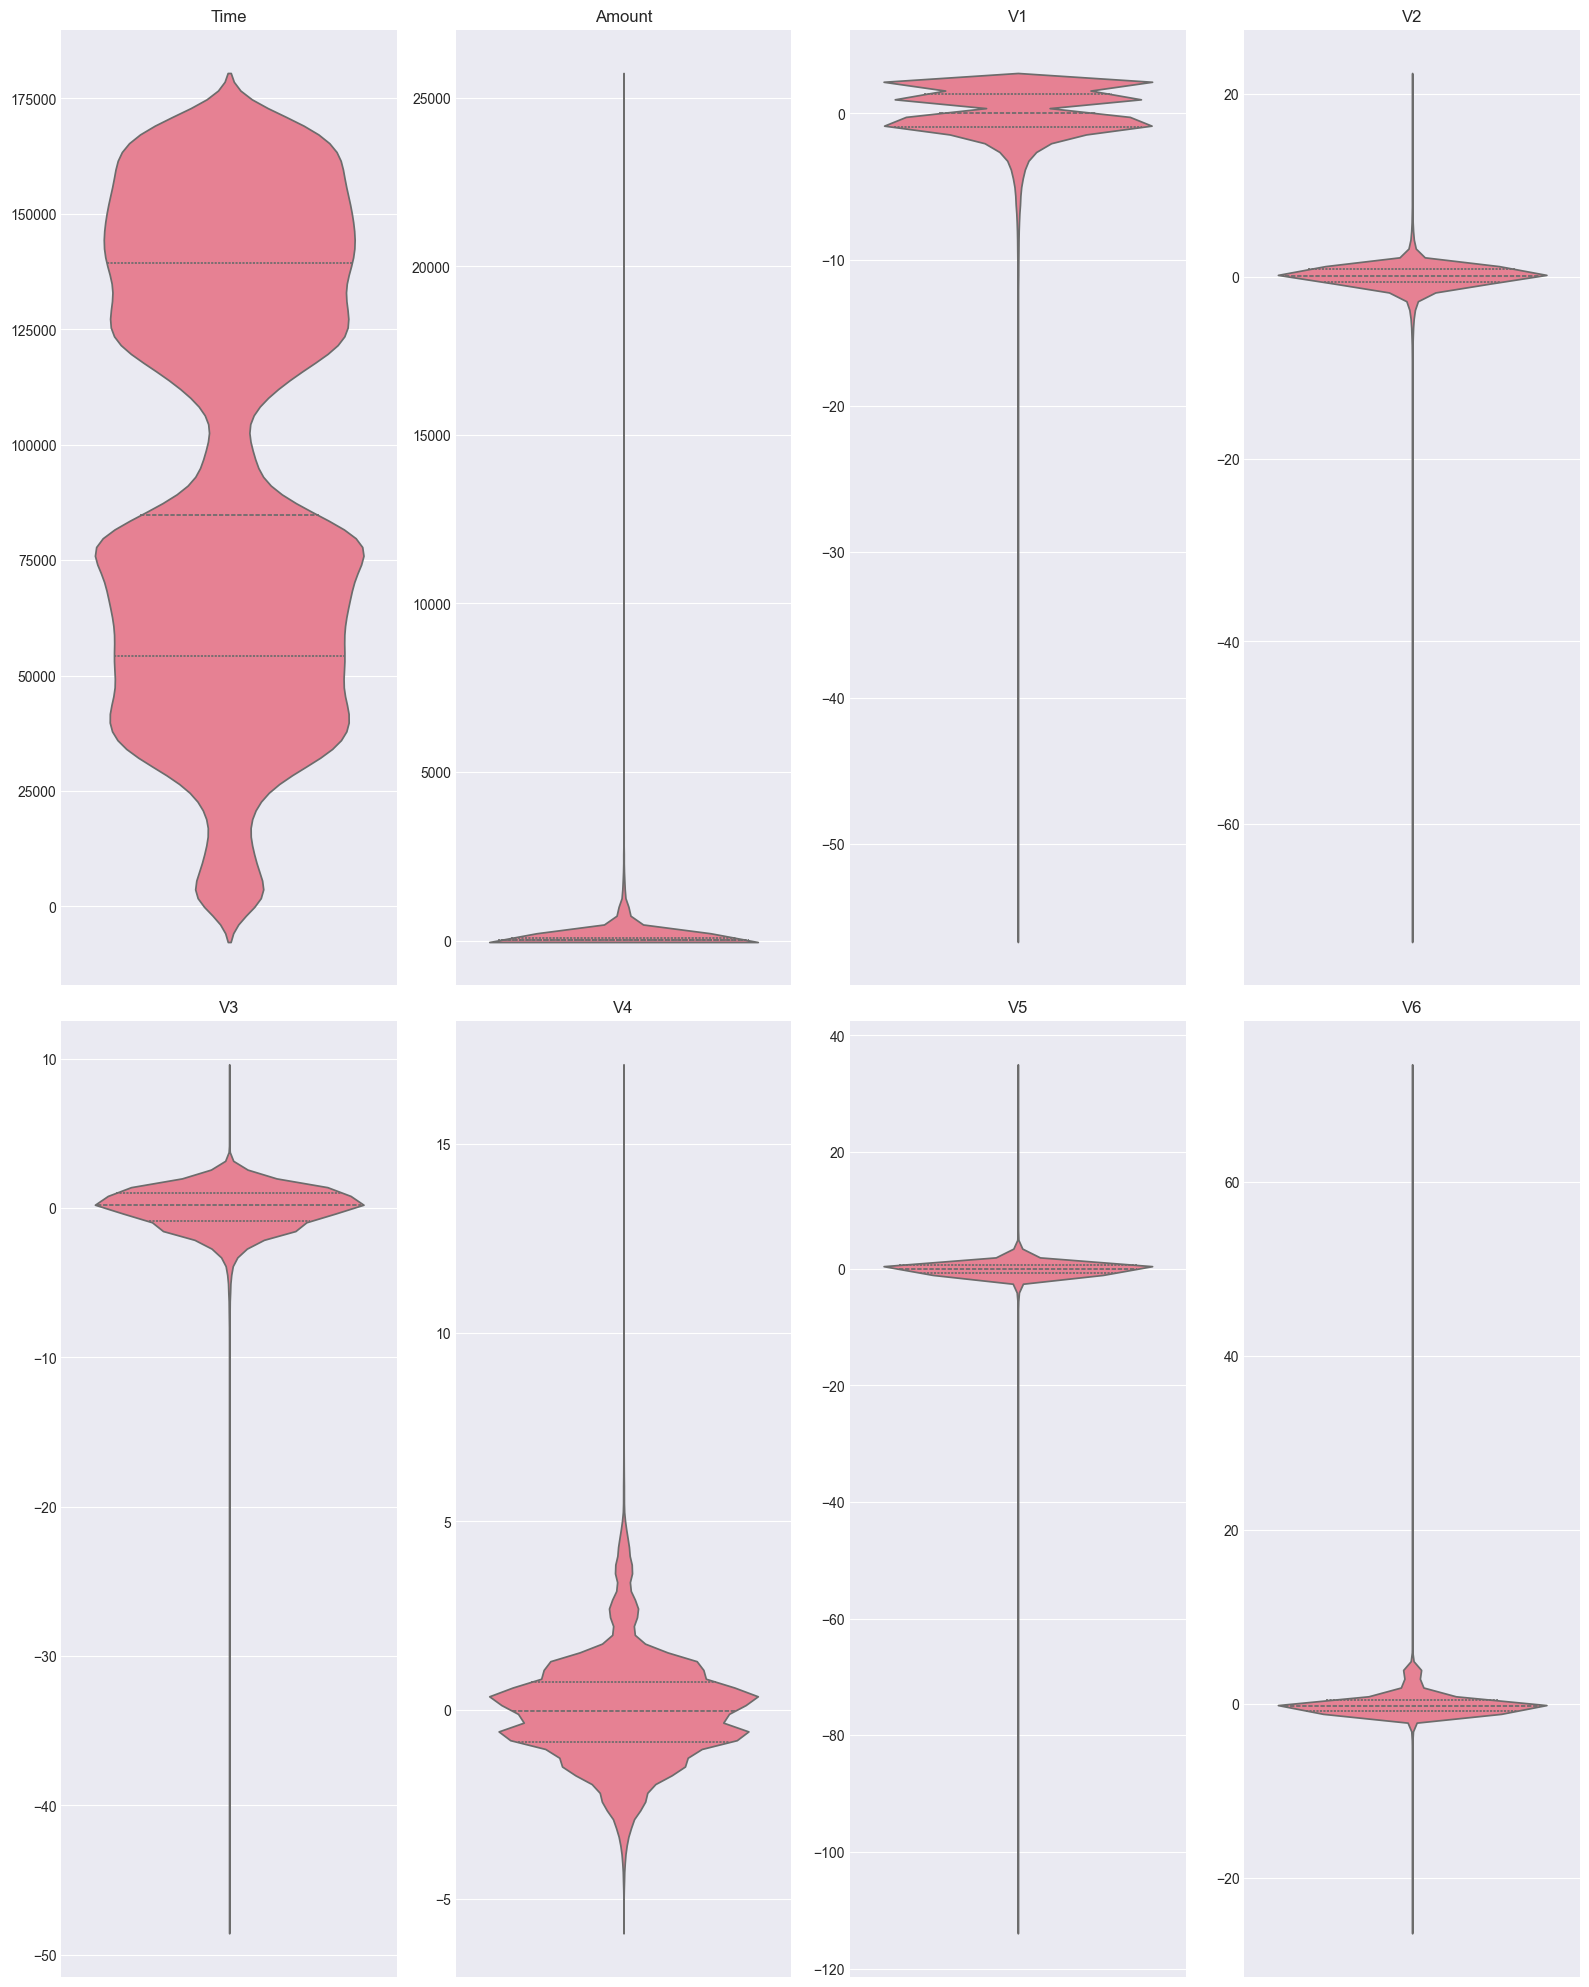

In [30]:
colunas = ['Time', 'Amount'] + [f'V{i}' for i in range(1, 7)]

fig, axes = plt.subplots(2, 4, figsize=(16, 20))
axes = axes.flatten()

for i, col in enumerate(colunas):
    sns.violinplot(y=df[col], ax=axes[i], inner='quartile')
    axes[i].set_title(col)
    axes[i].set_ylabel('')

plt.tight_layout()
plt.show()

### Decisão adotada quanto aos outliers

- **Não removemos outliers** das features V1-V28
- **Não removemos outliers** da coluna `Amount`
- Apenas garantimos que não há valores impossíveis:
  - `Time >= 0` (tempo não pode ser negativo)
  - `Amount >= 0` (valor não pode ser negativo)

### Por que não remover?

Remover outliers tem chances muito grandes de **remover justamente o que queremos detectar** — os padrões anômalos são os que mais costumam caracterizar fraudes.

In [34]:
# Única limpeza necessária:
df = df[df['Amount'] >= 0]  # garantir que não há valor negativo
df = df[df['Time'] >= 0]     # garantir que não há tempo negativo

# Normalização

Para a normalização, vamos usar funções do scikit learn. No caso, o RobustScaler.

## RobustScaler

O `RobustScaler` é um método de normalização que não é influenciado pelos outliers. Como neste dataset queremos preservar os outliers (que podem indicar fraudes), o RobustScaler é a escolha adequada para normalizar as colunas `Time` e `Amount` sem distorcer a distribuição dos dados.
Ele é cálculado a partir de **subtrair a mediana de todos os dados** e **escalar os dados** de acordo com o intervalo interquartil (IQR).

### Fórmula
X_scaled = (X - mediana) / IQR

Onde:
- **IQR** = Q3 - Q1 (diferença entre o terceiro e o primeiro quartil)




In [56]:
# como as demais colunas são PCA, não vamos normalizá-las
from sklearn.preprocessing import RobustScaler

scaler = RobustScaler()
df[['Time', 'Amount']] = scaler.fit_transform(df[['Time', 'Amount']])

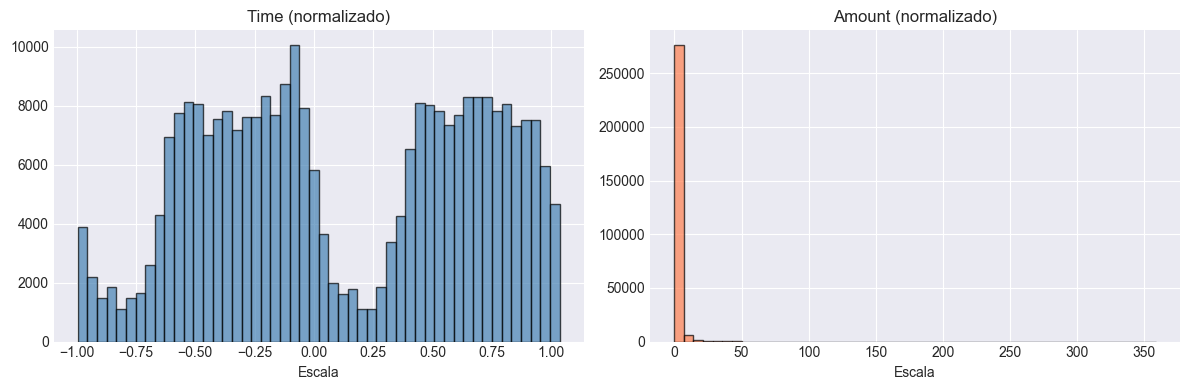

In [57]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Time
axes[0].hist(df['Time'], bins=50, color='steelblue', alpha=0.7, edgecolor='black')
axes[0].set_title('Time (normalizado)')
axes[0].set_xlabel('Escala')

# Amount
axes[1].hist(df['Amount'], bins=50, color='coral', alpha=0.7, edgecolor='black')
axes[1].set_title('Amount (normalizado)')
axes[1].set_xlabel('Escala')

plt.tight_layout()
plt.show()

# Treinamento de modelos

Vamos começar usando modelos mais simples, leves e menos precisos para termos uma referência base.

## Regressão Logística

1. **Calcula uma pontuação linear** combinando os valores das features com pesos aprendidos
2. **Aplica a função sigmoide** para transformar essa pontuação em uma probabilidade entre 0 e 1
3. **Classifica** com base em um limite (threshold): geralmente 0.5
```
probabilidade = 1 / (1 + e^(-(w₁x₁ + w₂x₂ + ... + b)))
```

### Por que foi escolhida como referência

- **Simplicidade**: é um dos modelos mais básicos para classificação binária
- **Baseline**: serve como ponto de partida mínimo — qualquer modelo mais complexo precisa superá-lo para justificar o uso
- **Interpretabilidade**: os coeficientes mostram claramente a importância de cada feature
- **Eficiência**: treina rapidamente mesmo em datasets grandes
- **Nativa no scikit-learn**: não requer bibliotecas adicionais


In [74]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_auc_score, precision_score, recall_score, f1_score

# Separar treino/teste
X = df.drop('Class', axis=1)
y = df['Class']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=42
)

# Treinar com class_weight
lr = LogisticRegression(class_weight='balanced', max_iter=1000)
lr.fit(X_train, y_train)

# Avaliar
y_pred_lr = lr.predict(X_test)
y_proba_lr = lr.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred_lr))
print(f"AUC: {roc_auc_score(y_test, y_proba_lr):.4f}")

# Guardar métricas
precision_lr = precision_score(y_test, y_pred_lr)
recall_lr = recall_score(y_test, y_pred_lr)
f1_lr = f1_score(y_test, y_pred_lr)
auc_lr = roc_auc_score(y_test, y_proba_lr)

              precision    recall  f1-score   support

           0       1.00      0.98      0.99     85295
           1       0.07      0.88      0.12       148

    accuracy                           0.98     85443
   macro avg       0.53      0.93      0.56     85443
weighted avg       1.00      0.98      0.99     85443

AUC: 0.9679


## Precision, Recall e F1-Score

### Precision (Precisão)

**Das transações que o modelo marcou como fraude, quantas realmente eram?**

- Fórmula: `VP / (VP + FP)`
- No caso acima: Precision = 0.07 → 7% dos alertas de fraude estavam corretos

### Recall (Cobertura)

**Das fraudes reais, quantas o modelo conseguiu detectar?**

- Fórmula: `VP / (VP + FN)`
- No caso acima: Recall = 0.88 → detectou 88% das fraudes que aconteceram

### F1-Score

**Média harmônica entre precision e recall.**

- Fórmula: `2 × (precision × recall) / (precision + recall)`
- Útil quando você precisa equilibrar os dois
- No caso acima: 0.12 → 12%

### No contexto de fraude

- **Precision alta** = menos falsos alertas (clientes não são incomodados à toa)
- **Recall alto** = menos fraudes passam despercebidas
- **F1 alto** = bom equilíbrio entre os dois

## AUC e ROC

**ROC** (Receiver Operating Characteristic): curva que mostra o desempenho do modelo em todos os possíveis thresholds. No eixo X está a taxa de falsos positivos; no eixo Y, a taxa de verdadeiros positivos (recall).

**AUC** (Area Under the Curve): área abaixo da curva ROC. Mede a capacidade do modelo de distinguir entre as classes.

| AUC       | Significado                        |
|-----------|------------------------------------|
| 0.0 - 0.5 | Modelo aleatório (não separa nada) |
| 0.7 - 0.8 | Aceitável                          |
| 0.8 - 0.9 | Bom                                |
| 0.9 - 1.0 | Excelente                          |

**Vantagem**: avalia o modelo independentemente do threshold escolhido.

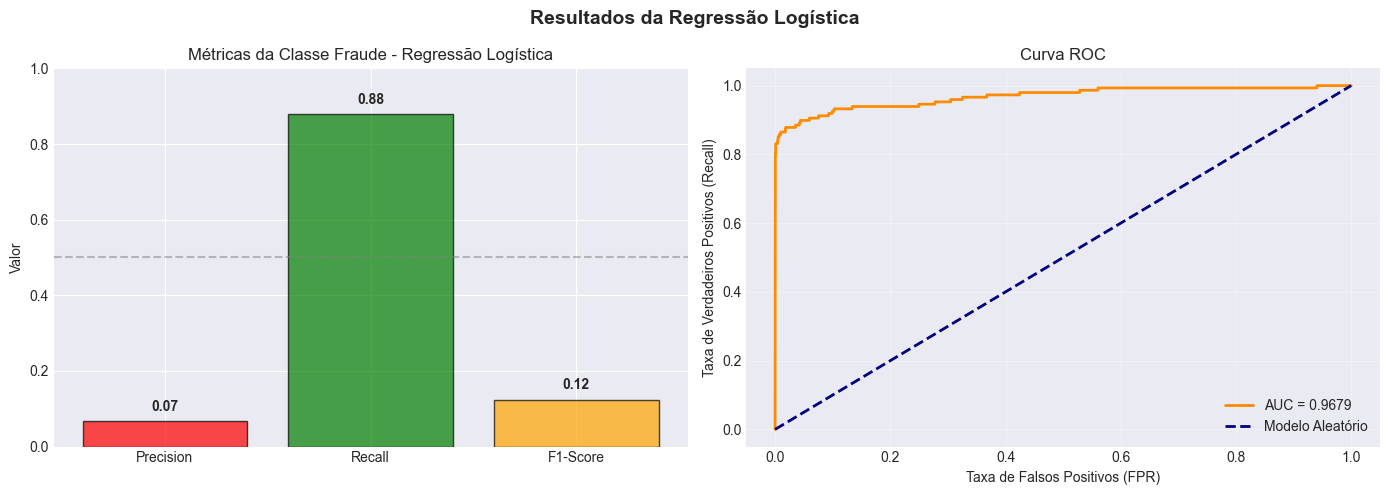

In [77]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import roc_curve

# Usando as variáveis já calculadas do bloco da regressão logística
precision_fraude = precision_lr
recall_fraude = recall_lr
f1_fraude = f1_lr
auc = auc_lr

# 1. Gráfico de barras comparando as métricas da classe fraude
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico 1: Métricas da classe fraude
metricas = ['Precision', 'Recall', 'F1-Score']
valores = [precision_fraude, recall_fraude, f1_fraude]
cores = ['red', 'green', 'orange']

bars = axes[0].bar(metricas, valores, color=cores, alpha=0.7, edgecolor='black')
axes[0].set_ylim(0, 1)
axes[0].set_ylabel('Valor')
axes[0].set_title('Métricas da Classe Fraude - Regressão Logística')
axes[0].axhline(y=0.5, color='gray', linestyle='--', alpha=0.5)

# Adicionar valores nas barras
for bar, valor in zip(bars, valores):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02, 
                f'{valor:.2f}', ha='center', va='bottom', fontweight='bold')

# 2. Curva ROC
fpr, tpr, _ = roc_curve(y_test, y_proba_lr)

axes[1].plot(fpr, tpr, color='darkorange', lw=2, label=f'AUC = {auc:.4f}')
axes[1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Modelo Aleatório')
axes[1].set_xlabel('Taxa de Falsos Positivos (FPR)')
axes[1].set_ylabel('Taxa de Verdadeiros Positivos (Recall)')
axes[1].set_title('Curva ROC')
axes[1].legend(loc='lower right')
axes[1].grid(True, alpha=0.3)

plt.suptitle('Resultados da Regressão Logística', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [75]:
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, roc_auc_score, precision_score, recall_score, f1_score

# Calcular scale_pos_weight
scale = len(y_train[y_train==0]) / len(y_train[y_train==1])

# Treinar XGBoost
xgb = XGBClassifier(
    scale_pos_weight=scale,
    eval_metric='auc',
    random_state=42
)

xgb.fit(X_train, y_train)

# Avaliar
y_pred_xgb = xgb.predict(X_test)
y_proba_xgb = xgb.predict_proba(X_test)[:, 1]

print("\n=== XGBOOST ===")
print(classification_report(y_test, y_pred_xgb))
print(f"AUC: {roc_auc_score(y_test, y_proba_xgb):.4f}")

# Guardar métricas
precision_xgb = precision_score(y_test, y_pred_xgb)
recall_xgb = recall_score(y_test, y_pred_xgb)
f1_xgb = f1_score(y_test, y_pred_xgb)
auc_xgb = roc_auc_score(y_test, y_proba_xgb)


=== XGBOOST ===
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     85295
           1       0.88      0.79      0.83       148

    accuracy                           1.00     85443
   macro avg       0.94      0.90      0.92     85443
weighted avg       1.00      1.00      1.00     85443

AUC: 0.9705


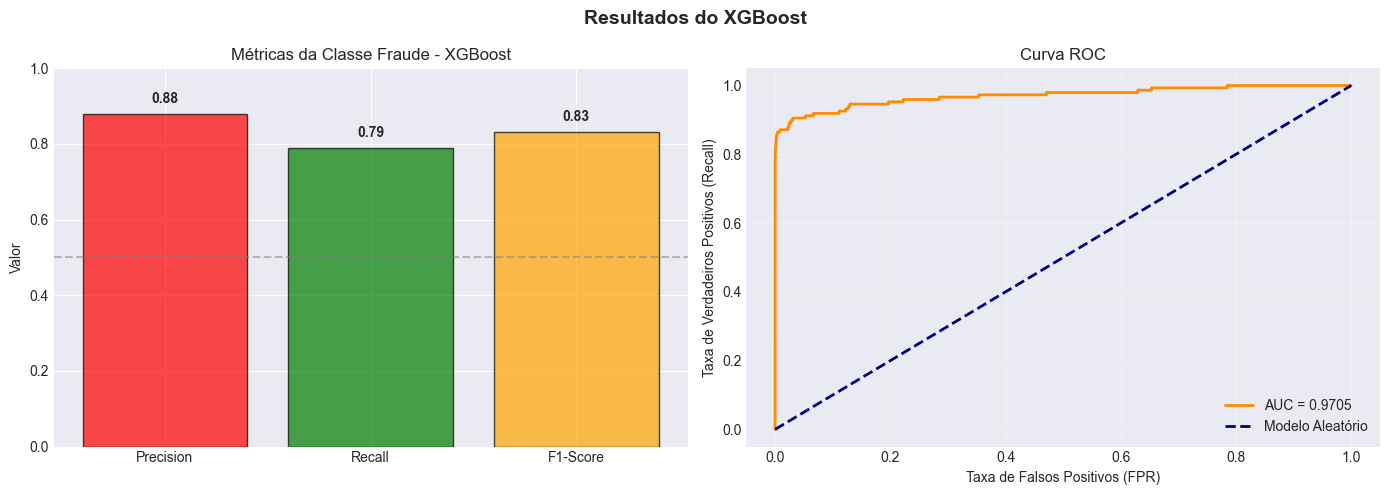

In [78]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import roc_curve

# Usando as variáveis já calculadas do bloco do XGBoost
precision_fraude = precision_xgb
recall_fraude = recall_xgb
f1_fraude = f1_xgb
auc = auc_xgb

# 1. Gráfico de barras comparando as métricas da classe fraude
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico 1: Métricas da classe fraude
metricas = ['Precision', 'Recall', 'F1-Score']
valores = [precision_fraude, recall_fraude, f1_fraude]
cores = ['red', 'green', 'orange']

bars = axes[0].bar(metricas, valores, color=cores, alpha=0.7, edgecolor='black')
axes[0].set_ylim(0, 1)
axes[0].set_ylabel('Valor')
axes[0].set_title('Métricas da Classe Fraude - XGBoost')
axes[0].axhline(y=0.5, color='gray', linestyle='--', alpha=0.5)

# Adicionar valores nas barras
for bar, valor in zip(bars, valores):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02, 
                f'{valor:.2f}', ha='center', va='bottom', fontweight='bold')

# 2. Curva ROC
fpr, tpr, _ = roc_curve(y_test, y_proba_xgb)

axes[1].plot(fpr, tpr, color='darkorange', lw=2, label=f'AUC = {auc:.4f}')
axes[1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Modelo Aleatório')
axes[1].set_xlabel('Taxa de Falsos Positivos (FPR)')
axes[1].set_ylabel('Taxa de Verdadeiros Positivos (Recall)')
axes[1].set_title('Curva ROC')
axes[1].legend(loc='lower right')
axes[1].grid(True, alpha=0.3)

plt.suptitle('Resultados do XGBoost', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

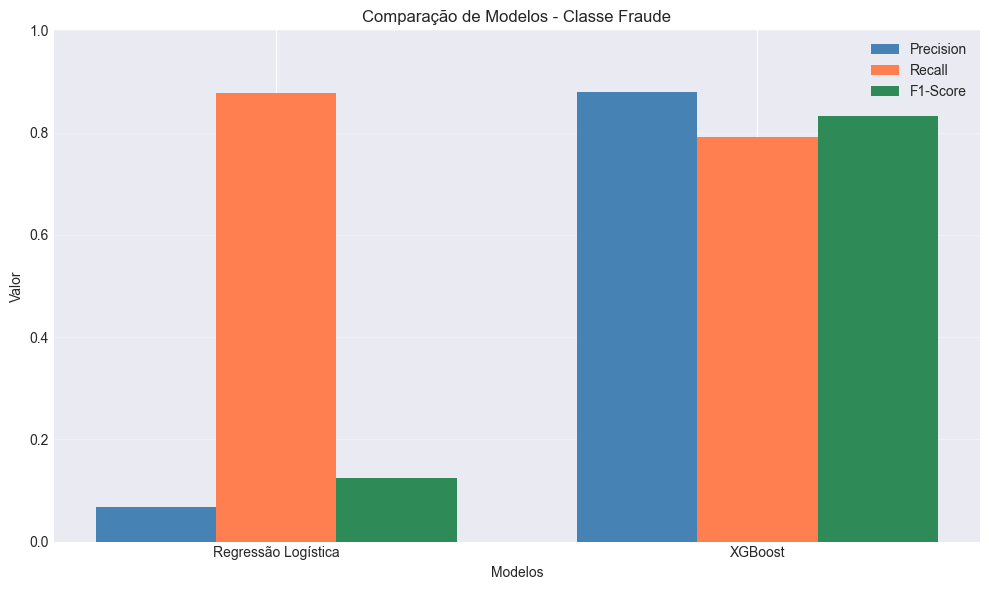


Comparação AUC:
Regressão Logística: 0.9679
XGBoost: 0.9705


In [76]:
import matplotlib.pyplot as plt
import numpy as np

modelos = ['Regressão Logística', 'XGBoost']
precision = [precision_lr, precision_xgb]
recall = [recall_lr, recall_xgb]
f1 = [f1_lr, f1_xgb]

x = np.arange(len(modelos))
width = 0.25

fig, ax = plt.subplots(figsize=(10, 6))

ax.bar(x - width, precision, width, label='Precision', color='steelblue')
ax.bar(x, recall, width, label='Recall', color='coral')
ax.bar(x + width, f1, width, label='F1-Score', color='seagreen')

ax.set_xlabel('Modelos')
ax.set_ylabel('Valor')
ax.set_title('Comparação de Modelos - Classe Fraude')
ax.set_xticks(x)
ax.set_xticklabels(modelos)
ax.legend()
ax.set_ylim(0, 1)
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print(f"\nComparação AUC:")
print(f"Regressão Logística: {auc_lr:.4f}")
print(f"XGBoost: {auc_xgb:.4f}")

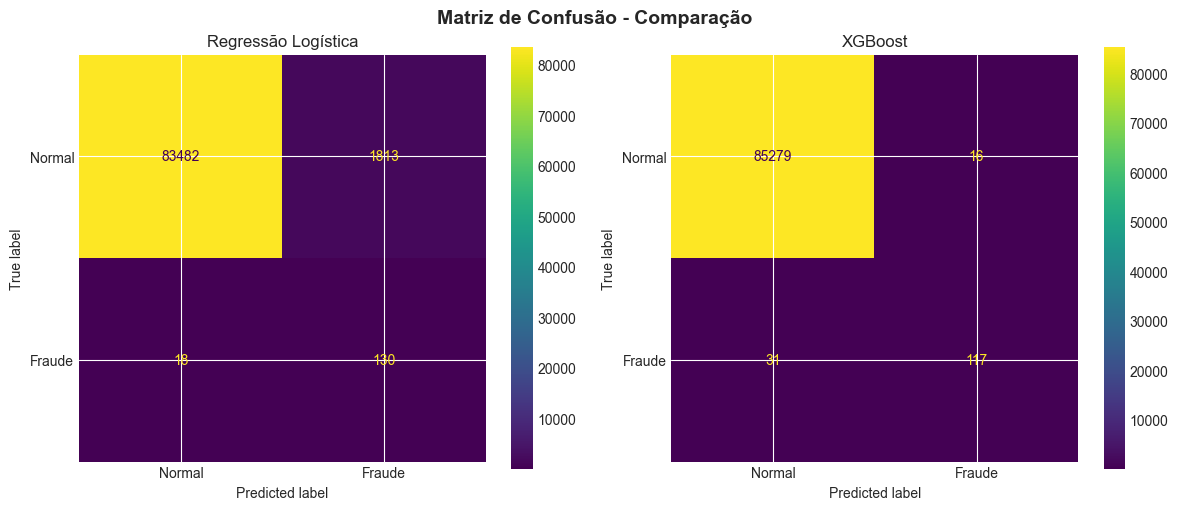

Matriz de Confusão - Regressão Logística:
Verdadeiros Negativos: 83,482
Falsos Positivos: 1,813
Falsos Negativos: 18
Verdadeiros Positivos: 130

Matriz de Confusão - XGBoost:
Verdadeiros Negativos: 85,279
Falsos Positivos: 16
Falsos Negativos: 31
Verdadeiros Positivos: 117


In [79]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Matriz de confusão para Regressão Logística
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# LR
cm_lr = confusion_matrix(y_test, y_pred_lr)
disp_lr = ConfusionMatrixDisplay(confusion_matrix=cm_lr, display_labels=['Normal', 'Fraude'])
disp_lr.plot(ax=axes[0], values_format='d')
axes[0].set_title('Regressão Logística')

# XGBoost
cm_xgb = confusion_matrix(y_test, y_pred_xgb)
disp_xgb = ConfusionMatrixDisplay(confusion_matrix=cm_xgb, display_labels=['Normal', 'Fraude'])
disp_xgb.plot(ax=axes[1], values_format='d')
axes[1].set_title('XGBoost')

plt.suptitle('Matriz de Confusão - Comparação', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Exibir números
print("Matriz de Confusão - Regressão Logística:")
print(f"Verdadeiros Negativos: {cm_lr[0,0]:,}")
print(f"Falsos Positivos: {cm_lr[0,1]:,}")
print(f"Falsos Negativos: {cm_lr[1,0]:,}")
print(f"Verdadeiros Positivos: {cm_lr[1,1]:,}")

print("\nMatriz de Confusão - XGBoost:")
print(f"Verdadeiros Negativos: {cm_xgb[0,0]:,}")
print(f"Falsos Positivos: {cm_xgb[0,1]:,}")
print(f"Falsos Negativos: {cm_xgb[1,0]:,}")
print(f"Verdadeiros Positivos: {cm_xgb[1,1]:,}")